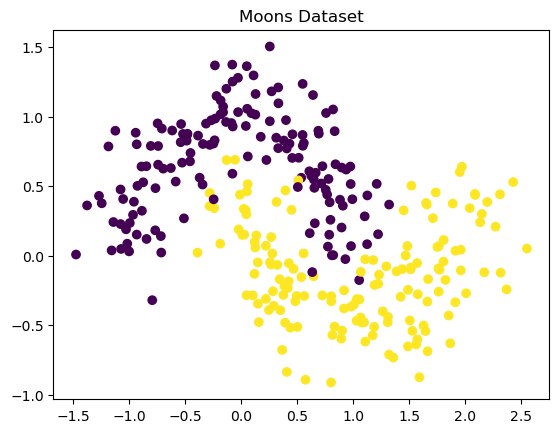

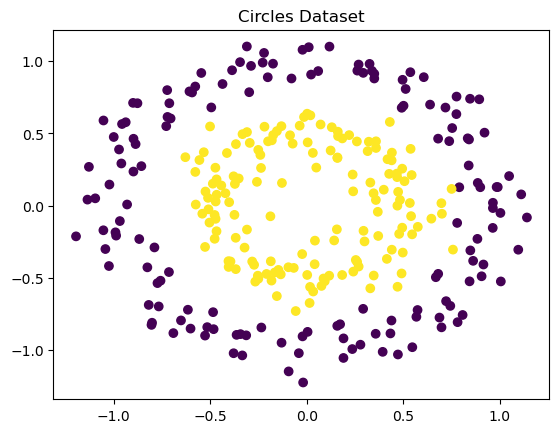

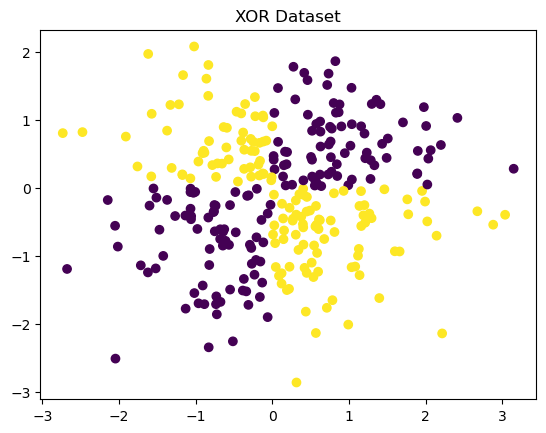

Linear Kernel Accuracy: 0.9
Polynomial Kernel Accuracy: 0.9111111111111111
RBF Kernel Accuracy: 0.9222222222222223
Sigmoid Kernel Accuracy: 0.6444444444444445


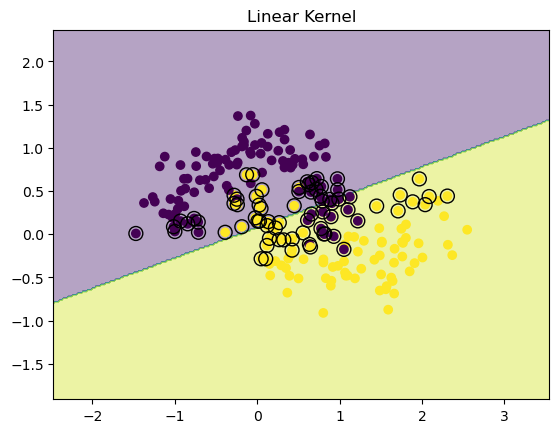

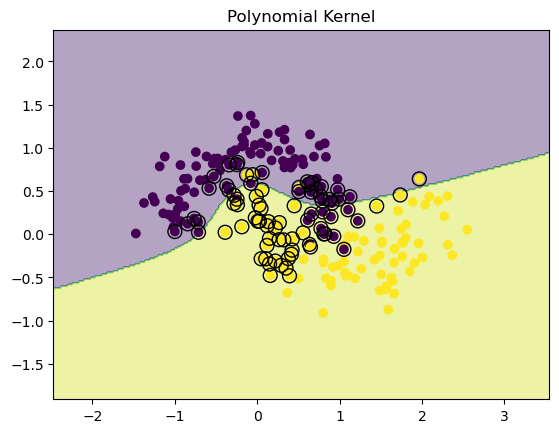

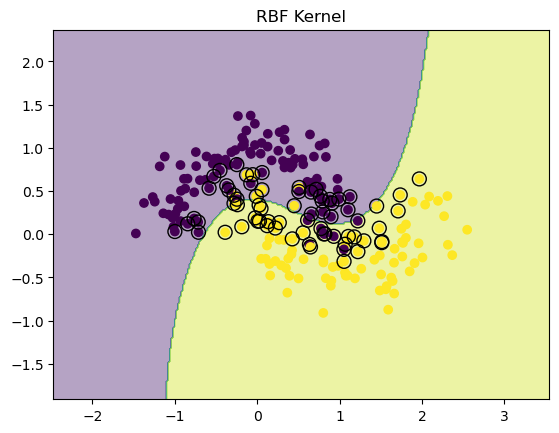

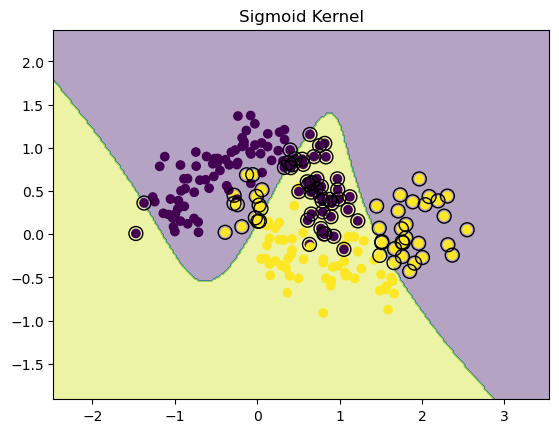

In [1]:
# EXPERIMENT 8 – SVM WITH DIFFERENT KERNELS

import numpy as np
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# -------------------------------
# PART A – DATA GENERATION
# -------------------------------

# Moons dataset
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)

# Circles dataset
X_circles, y_circles = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)

# XOR dataset
X_xor = np.random.randn(300,2)
y_xor = np.logical_xor(X_xor[:,0] > 0, X_xor[:,1] > 0)
y_xor = np.where(y_xor,1,0)

# Visualization
plt.scatter(X_moons[:,0], X_moons[:,1], c=y_moons)
plt.title("Moons Dataset")
plt.show()

plt.scatter(X_circles[:,0], X_circles[:,1], c=y_circles)
plt.title("Circles Dataset")
plt.show()

plt.scatter(X_xor[:,0], X_xor[:,1], c=y_xor)
plt.title("XOR Dataset")
plt.show()


# -------------------------------
# Train-Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons, test_size=0.3, random_state=42)


# -------------------------------
# PART B – SVM IMPLEMENTATION
# -------------------------------

# Linear Kernel
svm_linear = svm.SVC(kernel='linear', C=1)
svm_linear.fit(X_train, y_train)

pred_linear = svm_linear.predict(X_test)
print("Linear Kernel Accuracy:", accuracy_score(y_test, pred_linear))


# Polynomial Kernel
svm_poly = svm.SVC(kernel='poly', degree=3, C=1)
svm_poly.fit(X_train, y_train)

pred_poly = svm_poly.predict(X_test)
print("Polynomial Kernel Accuracy:", accuracy_score(y_test, pred_poly))


# RBF Kernel
svm_rbf = svm.SVC(kernel='rbf', gamma=0.5, C=1)
svm_rbf.fit(X_train, y_train)

pred_rbf = svm_rbf.predict(X_test)
print("RBF Kernel Accuracy:", accuracy_score(y_test, pred_rbf))


# Sigmoid Kernel
svm_sigmoid = svm.SVC(kernel='sigmoid', C=1)
svm_sigmoid.fit(X_train, y_train)

pred_sigmoid = svm_sigmoid.predict(X_test)
print("Sigmoid Kernel Accuracy:", accuracy_score(y_test, pred_sigmoid))


# -------------------------------
# PART C – DECISION BOUNDARY
# -------------------------------

def plot_decision_boundary(model, X, y, title):

    h = .02
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:,0], X[:,1], c=y)

    plt.scatter(model.support_vectors_[:,0],
                model.support_vectors_[:,1],
                s=100,
                facecolors='none',
                edgecolors='k')

    plt.title(title)
    plt.show()


plot_decision_boundary(svm_linear, X_train, y_train, "Linear Kernel")
plot_decision_boundary(svm_poly, X_train, y_train, "Polynomial Kernel")
plot_decision_boundary(svm_rbf, X_train, y_train, "RBF Kernel")
plot_decision_boundary(svm_sigmoid, X_train, y_train, "Sigmoid Kernel")
     